In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt

In [3]:
from synth_pat.paths import Paths

In [4]:
daniela = pd.read_csv(f'{Paths.DATA}/ALL_daniela_full_extracted_features.csv', index_col = 'pid')
traditional = pd.read_csv(f'{Paths.DATA}/ALL_traditional_full_extracted_features.csv', index_col = 'pid')

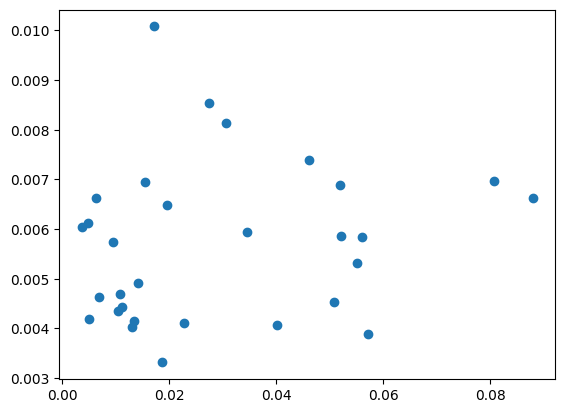

In [6]:
plt.scatter(traditional['GBC'], traditional['VAR_FCD'])

<Axes: >

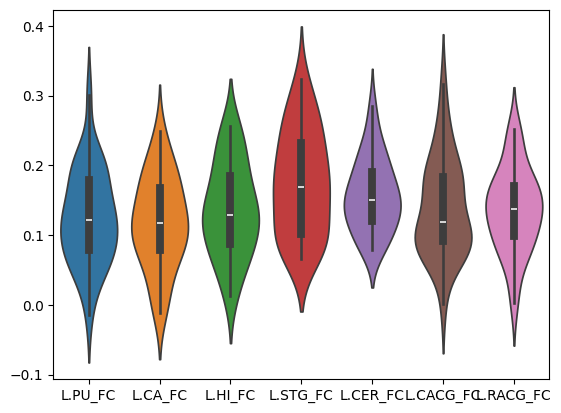

In [9]:
to_plot = ['L.PU_FC','L.CA_FC','L.HI_FC','L.STG_FC','L.CER_FC','L.CACG_FC','L.RACG_FC']
sns.violinplot(daniela[to_plot])

<Axes: >

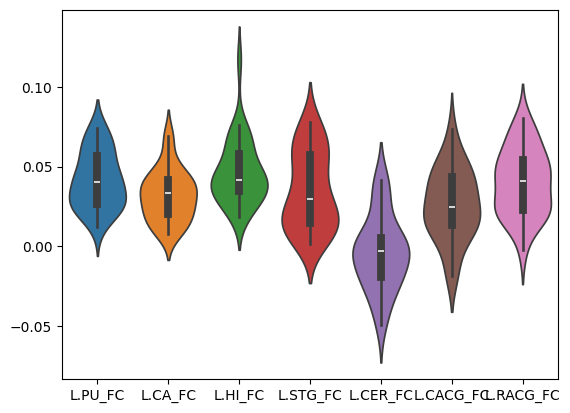

In [12]:
to_plot = ['L.PU_FC','L.CA_FC','L.HI_FC','L.STG_FC','L.CER_FC','L.CACG_FC','L.RACG_FC']
sns.violinplot(traditional[to_plot])

<Axes: >

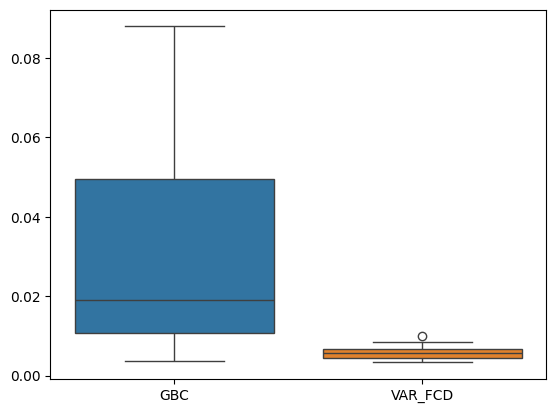

In [15]:
to_plot = ['GBC','VAR_FCD']
sns.boxplot(traditional[to_plot])

<Axes: >

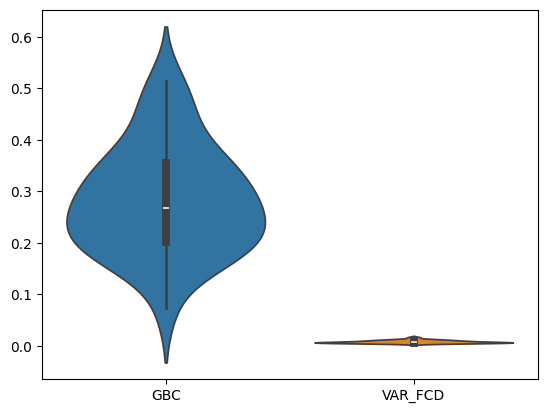

In [14]:
to_plot = ['GBC','VAR_FCD']
sns.violinplot(daniela[to_plot])

<Axes: >

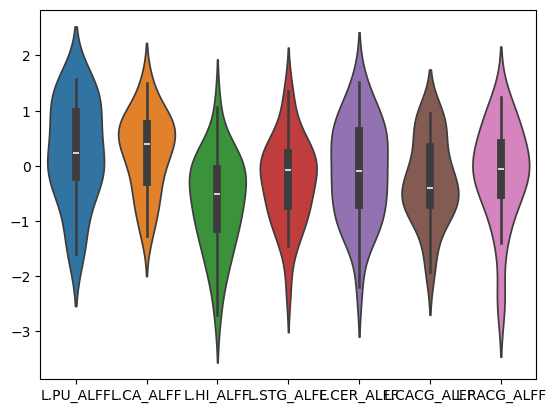

In [11]:
to_plot = ['L.PU_ALFF','L.CA_ALFF','L.HI_ALFF','L.STG_ALFF','L.CER_ALFF','L.CACG_ALFF','L.RACG_ALFF']
sns.violinplot(traditional[to_plot])

In [84]:
all_synth_df = []
for pid in os.listdir(Paths.RESULTS):
    file_dir = f'{Paths.RESULTS}/{pid}/bold_sweep_extracted_features.csv'
    df = pd.read_csv(file_dir, index_col=0)
    all_synth_df.append(df)

synth_res_df = pd.concat(all_synth_df, axis=0)

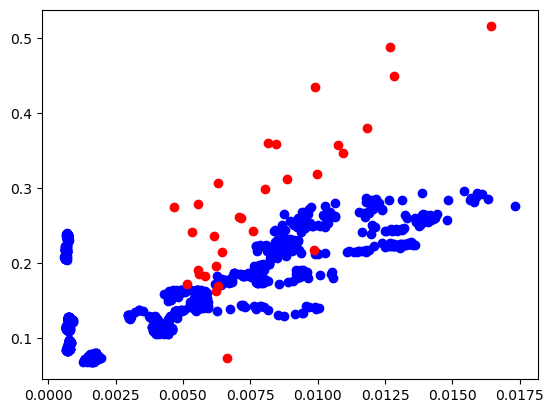

In [53]:
plt.scatter(synth_res_df['VAR_FCD'], synth_res_df['GBC'], c='b')
plt.scatter(daniela['VAR_FCD'], daniela['GBC'], c='r')


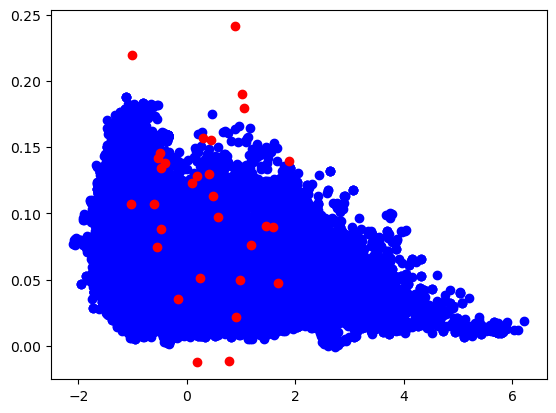

In [12]:
plt.scatter(synth_res_df['R.CA_ALFF'], synth_res_df['R.CA_FC'], c='b')
plt.scatter(daniela['R.CA_ALFF'], daniela['R.CA_FC'], c='r')

In [147]:
from synth_pat.scripts.analysis_utils import drop_high_corr_features

feat_df_reduced = drop_high_corr_features(synth_res_df)

Dropped 8 features


In [173]:
demo = pd.read_csv('/home/prior/gp_home/scadv/data/full_demographics.csv', index_col='SubjectID')
traditional['diagnosis'] = demo['diagnosis']

In [174]:
syntpat_df = pd.read_csv(f'{Paths.RESOURCES}/synth_pat_extracted_features.csv', index_col=0)
feat_df_reduced = drop_high_corr_features(syntpat_df)

Dropped 28 features


In [175]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

params = ['ws', 'njdopa_ctx', 'njdopa_str']
X_train_df = feat_df_reduced.drop(columns=params)
sc = StandardScaler()
X_train = sc.fit_transform(X_train_df.values)
pca = PCA(n_components=5)
X_train_r = pca.fit_transform(X_train)

X_test = sc.transform(traditional[X_train_df.columns].values)
X_test_r = pca.transform(X_test)


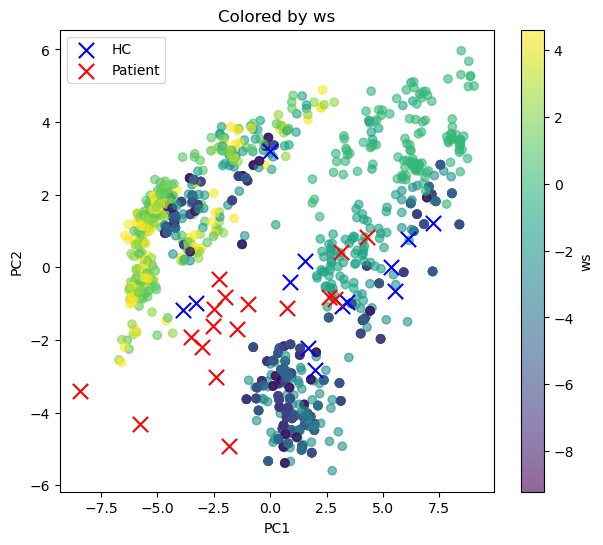

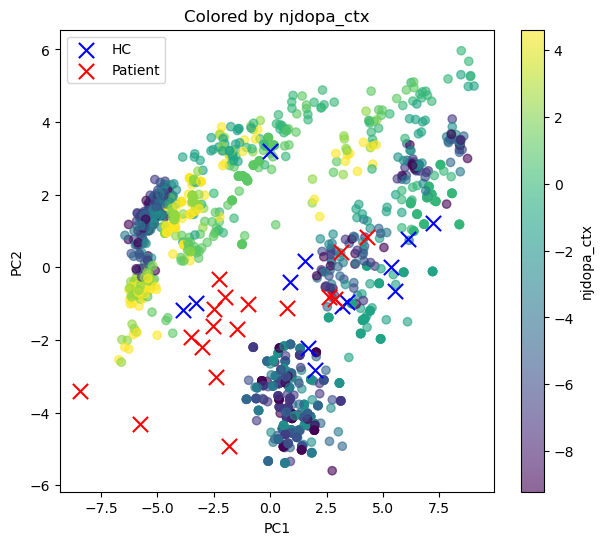

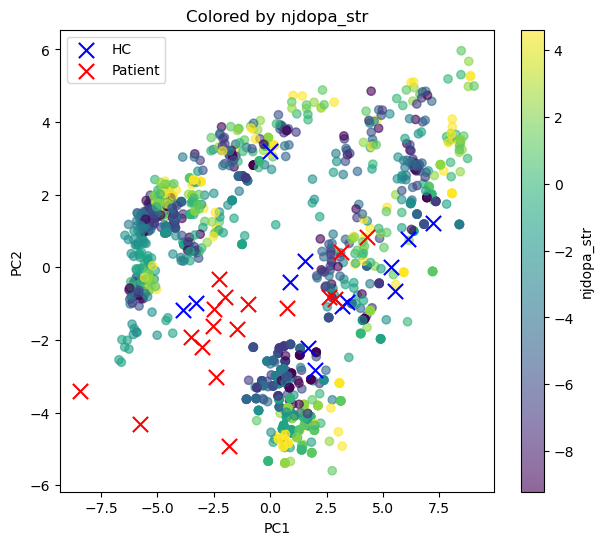

In [176]:
import matplotlib.pyplot as plt
import numpy as np

for param in params:

    plt.figure(figsize=(7,6))

    # --- TRAIN (simulations) ---
    sc = plt.scatter(
        X_train_r[:,0],
        X_train_r[:,1],
        c=np.log(syntpat_df[param]),
        alpha=0.6
    )

    plt.colorbar(sc, label=param)

    # --- TEST (empirical) ---
    hc_mask = traditional['diagnosis'] == 'HC'
    pat_mask = traditional['diagnosis'] != 'HC'  # adjust if needed

    # HC subjects
    plt.scatter(
        X_test_r[hc_mask,0],
        X_test_r[hc_mask,1],
        c='blue',
        marker='x',
        s=120,
        label='HC'
    )

    # Patients
    plt.scatter(
        X_test_r[pat_mask,0],
        X_test_r[pat_mask,1],
        c='red',
        marker='x',
        s=120,
        label='Patient'
    )

    plt.title(f'Colored by {param}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.show()

In [139]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

params = ['ws', 'njdopa_ctx', 'njdopa_str']
X_train_df = synth_res_df.drop(columns=params)
X_train = StandardScaler().fit_transform(X_train_df.values)
pca = PCA(n_components=20)
X_train_r = pca.fit_transform(X_train)

X_test = StandardScaler().fit_transform(daniela[X_train_df.columns].values)

# t-SNE projection
tsne = TSNE(
    n_components=2,
    perplexity=100,        # adjust if needed
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_train_TNSE = tsne.fit_transform(X_train_r)
#X_test_r = tsne.fit_transform(X_test)

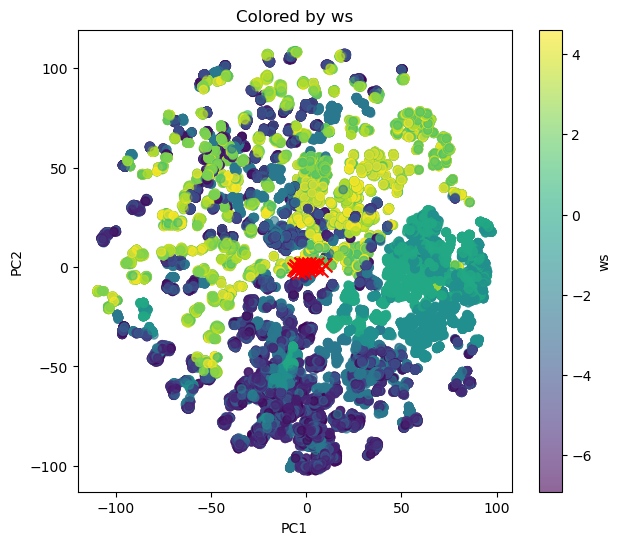

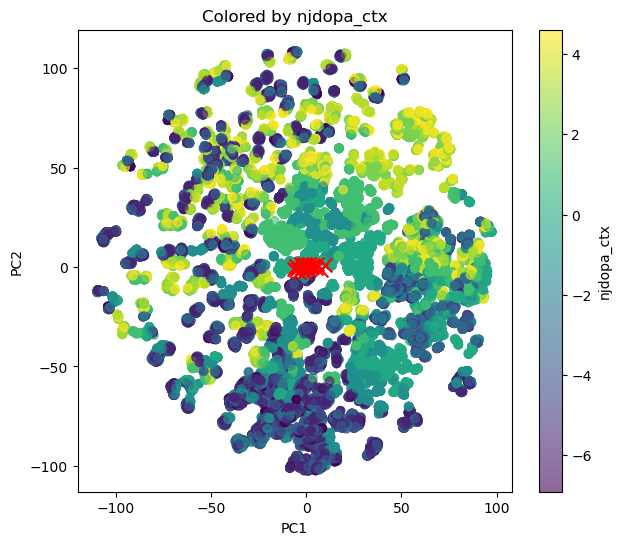

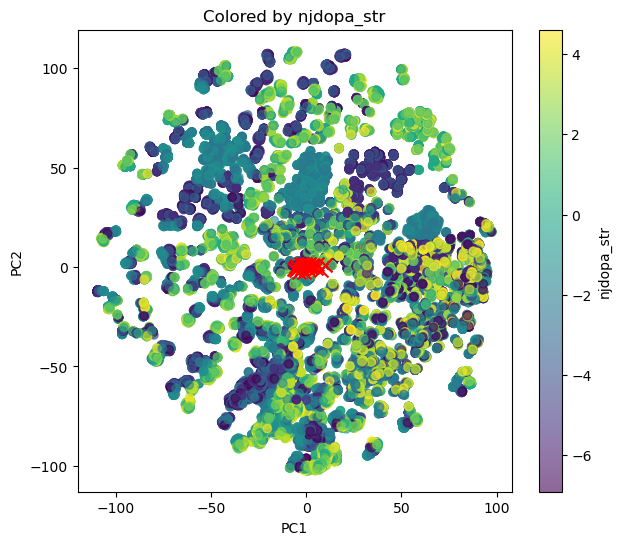

In [141]:
for param in params:
    plt.figure(figsize=(7,6))
    
    sc = plt.scatter(
        X_train_TNSE[:,0],
        X_train_TNSE[:,1],
        c=np.log(synth_res_df[param]),
        alpha=0.6
    )
    
    plt.colorbar(sc, label=param)
    
    plt.scatter(
        X_test_r[:,0],
        X_test_r[:,1],
        c='red',
        marker='x',
        s=100
    )
    
    plt.title(f'Colored by {param}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()

<Axes: ylabel='VAR_FCD'>

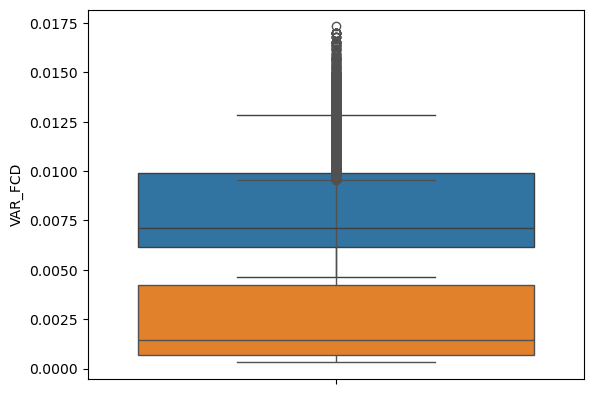

In [35]:
sns.boxplot(daniela['VAR_FCD'])
sns.boxplot(synth_res_df['VAR_FCD'])

In [46]:
synth_res_df

,GBC,VAR_FCD,ws,njdopa_ctx,njdopa_str,L.PU_FC,L.CA_FC,L.HI_FC,L.STG_FC,L.CER_FC,...,R.HI_ALFF,R.STG_ALFF,R.CER_ALFF,R.CACG_ALFF,R.RACG_ALFF,R.IN_ALFF,R.PCG_ALFF,R.POP_ALFF,R.POR_ALFF,R.PTR_ALFF
0,0.140459,0.004158,0.100,30.00,100.000,0.098083,0.078338,0.055276,0.079081,0.021925,...,-0.820223,0.666867,-0.395132,0.405702,-0.700970,1.455822,1.678349,1.154607,-1.103367,2.253386
1,0.107632,0.003244,0.003,3.00,0.100,-0.003314,0.052885,0.056321,0.075311,0.052372,...,-0.131011,0.515892,-0.445065,0.486936,0.059829,1.424524,0.213430,1.290734,-1.230517,4.030664
2,0.098566,0.000678,100.000,0.10,3.000,0.080823,0.091843,0.041659,0.045201,0.021068,...,0.290883,1.359760,-0.500392,0.706077,-0.509972,1.217164,1.264178,0.131353,-0.212120,2.897090
3,0.167951,0.004959,100.000,3.00,1.000,0.085664,0.066091,0.067390,0.105338,0.063135,...,-0.146378,1.009752,-0.997276,-0.221835,-0.409504,0.300198,1.577484,-0.144439,-0.810600,4.503904
4,0.154971,0.004830,30.000,3.00,0.001,0.051183,0.088601,0.061115,0.100598,0.021359,...,-0.179849,1.128727,-0.921551,-0.209633,-0.420546,0.345007,1.686052,-0.100462,-0.798014,4.657585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1326,0.136011,0.004916,0.030,3.00,1.000,0.085669,0.089232,0.058591,0.098826,-0.001408,...,-0.615359,1.300213,-1.032613,0.140538,-0.233316,0.367207,1.079483,0.203865,-1.117214,2.694867
1327,0.114666,0.003842,0.003,0.30,0.100,0.045148,0.083144,0.056655,0.062625,0.015138,...,-0.054545,0.294025,-0.580531,1.088174,0.430636,0.534294,0.904313,1.563824,1.365811,1.270965
1328,0.112475,0.000673,10.000,0.03,0.300,0.030729,0.055642,0.026997,0.086284,0.005366,...,-0.571737,1.300617,-0.742057,-0.265796,-0.612993,0.294785,1.237897,-0.349874,-0.766942,2.702476
1329,0.160845,0.004858,100.000,0.30,0.300,-0.005046,0.039609,0.053592,0.114623,0.006098,...,-0.555013,0.753224,-0.842396,-0.108974,-0.598116,0.126283,1.152418,-0.105334,0.882883,2.344873


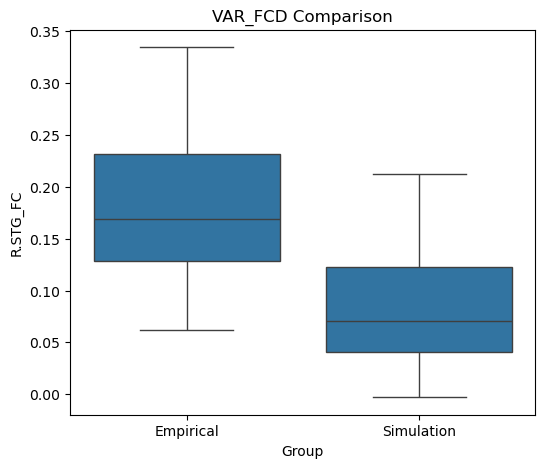

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature = "R.STG_FC"

df_plot = pd.DataFrame({
    feature: pd.concat([
        daniela[feature],
        synth_res_df[feature]
    ], ignore_index=True),
    "Group": (["Empirical"] * len(daniela)) +
             (["Simulation"] * len(synth_res_df))
})

plt.figure(figsize=(6,5))
sns.boxplot(data=df_plot, x="Group", y=feature)
plt.title("VAR_FCD Comparison")
plt.show()

In [5]:
demo = pd.read_csv('/home/prior/gp_home/scadv/data/full_demographics.csv', index_col='SubjectID')
traditional['diagnosis'] = demo['diagnosis']
daniela['diagnosis'] = demo['diagnosis']

In [9]:
from synth_pat.scripts.analysis_utils import drop_high_corr_features

feat_df_reduced = drop_high_corr_features(synth_res_df)

Dropped 9 features


sub-2015052501
Baseline 24 Male


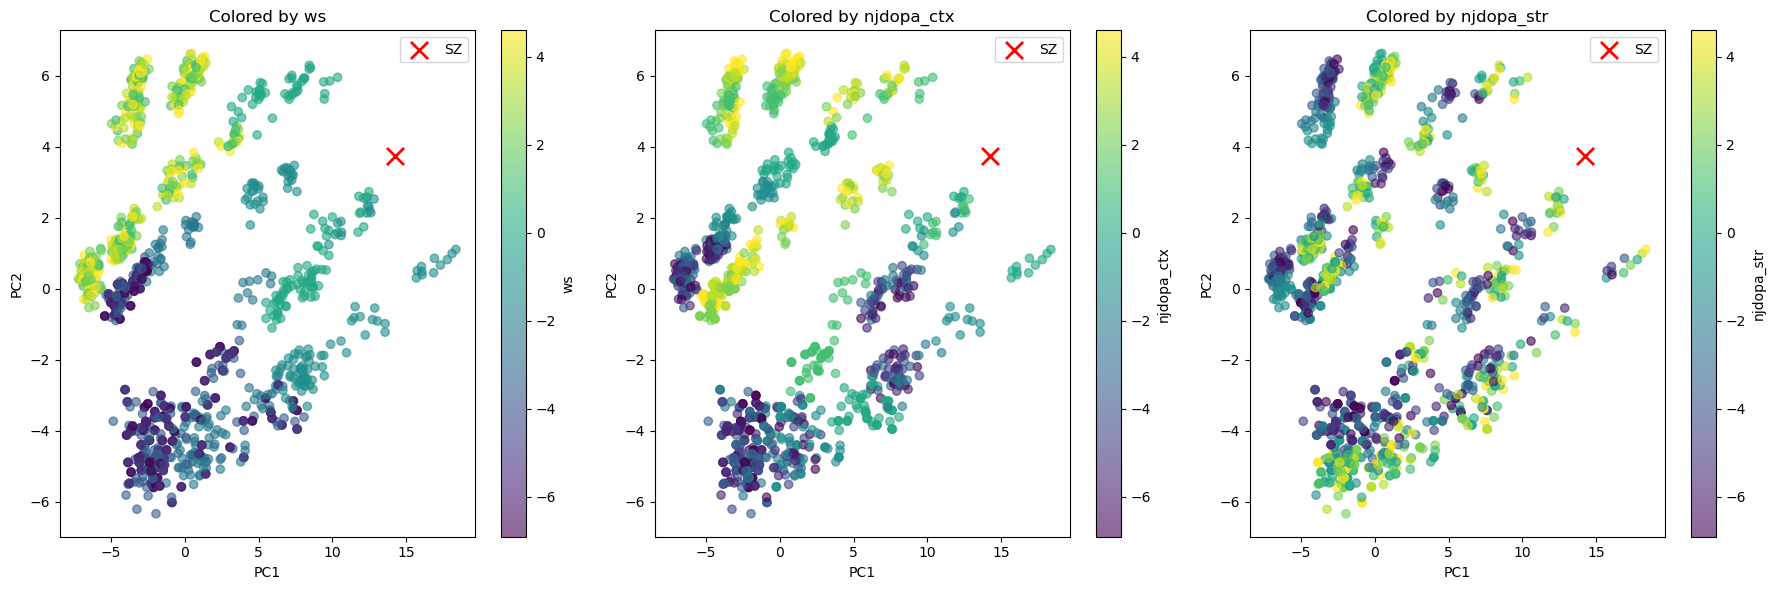

sub-2015120501
Followup 24 Male


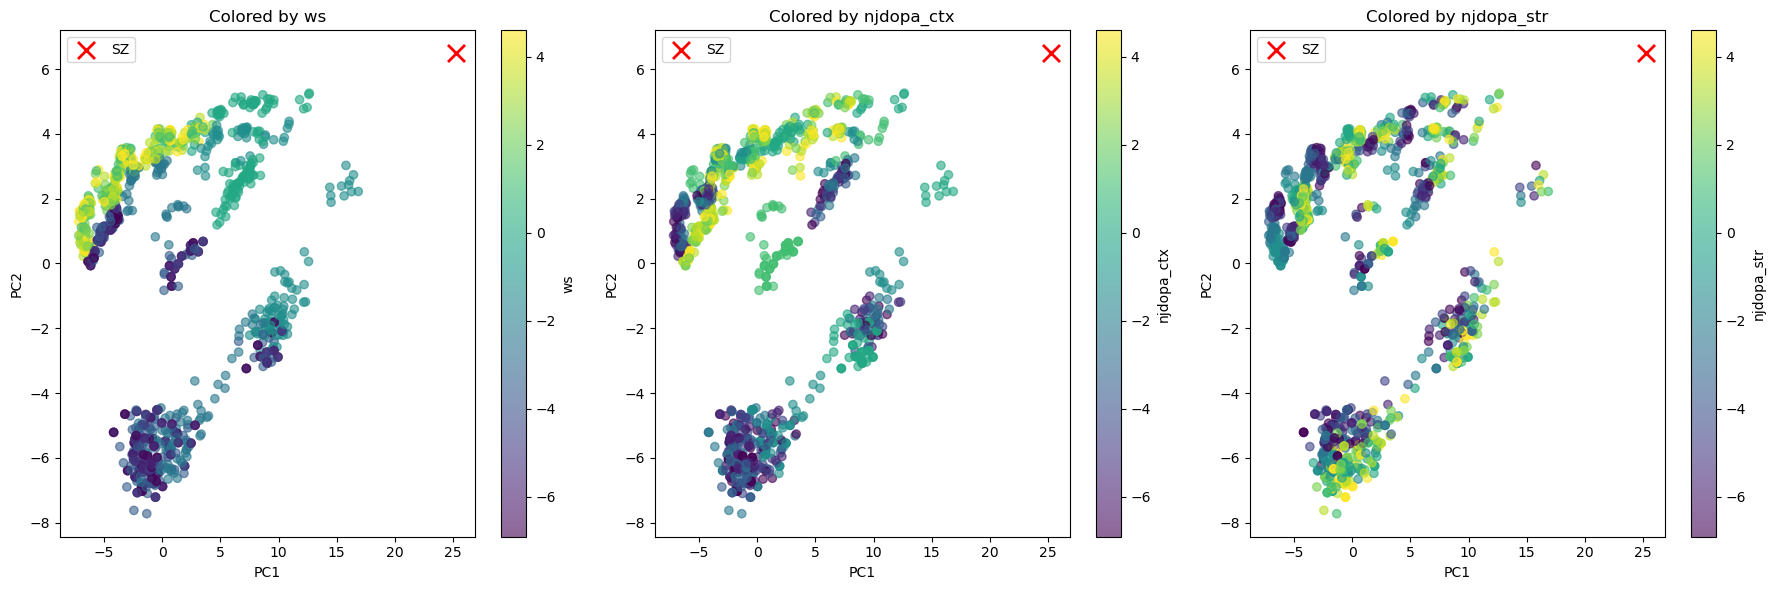

sub-2015120401
Followup 19 Female


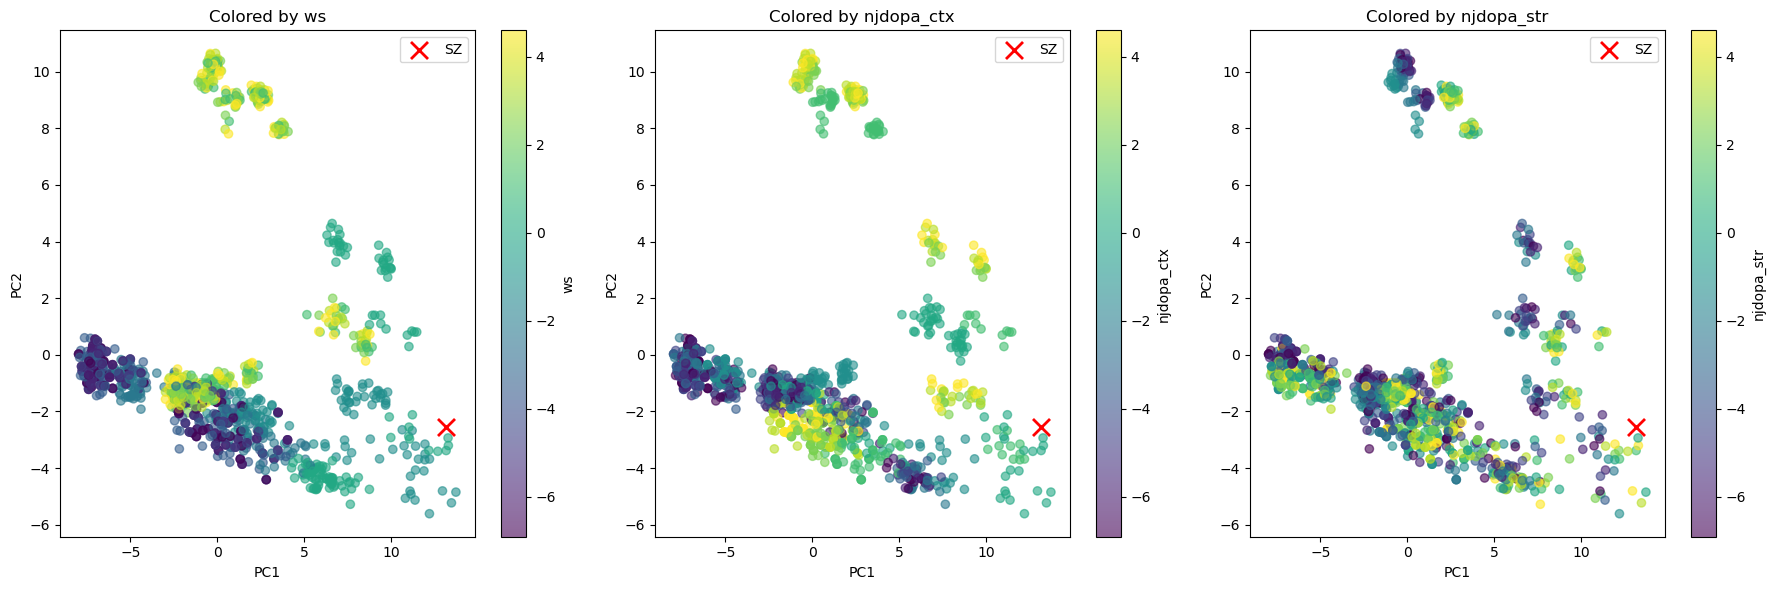

In [6]:
pid = 'sub-1198'
params = ['ws', 'njdopa_ctx', 'njdopa_str']
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
#for pid in [2015052501, 2015060902, 2015120501, 2015121001, 2019012101, 2019052301, 2015060401, 2015061901, 2015120401, 2015111402, 2019012402, 2019052302]: #os.listdir(Paths.RESULTS):
for pid in [2015052501, 2015120501, 2015120401]:
    pid = 'sub-' + str(pid)
    print(pid)
    pid_idx = int(pid.split('-')[1])
    print(demo.loc[pid_idx, 'wave'], demo.loc[pid_idx, 'age'], demo.loc[pid_idx, 'sex'])
    daniela_pid = daniela.loc[pid_idx]
    diagnosis = daniela.loc[pid_idx, 'diagnosis']
    file_dir = f'{Paths.RESULTS}/{pid}/bigger_we_bold_sweep_extracted_features.csv'
    synth_res_df = pd.read_csv(file_dir, index_col=0)
    #feat_df_reduced = drop_high_corr_features(synth_res_df)
    X_train_df = synth_res_df.drop(columns=params)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_df.values)
    pca = PCA(n_components=5)
    X_train_r = pca.fit_transform(X_train_scaled)

    X_test = daniela_pid[X_train_df.columns].values.reshape(1, -1)
    X_test_scaled = scaler.transform(X_test)
    X_test_r = pca.transform(X_test_scaled)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, param in enumerate(params):

        # --- TRAIN (simulations) ---
        sc = axes[i].scatter(
            X_train_r[:, 0],
            X_train_r[:, 1],
            c=np.log(synth_res_df[param]),
            alpha=0.6
        )

        # Add colorbar properly
        cbar = fig.colorbar(sc, ax=axes[i])
        cbar.set_label(param)

        # --- TEST (empirical subject) ---
        axes[i].scatter(
            X_test_r[0, 0],
            X_test_r[0, 1],
            c='red' if diagnosis != 'HC' else 'blue',
            marker='x',
            s=150,
            linewidths=2,
            label=diagnosis,
            zorder=10
        )

        axes[i].set_title(f'Colored by {param}')
        axes[i].set_xlabel('PC1')
        axes[i].set_ylabel('PC2')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

In [16]:
r = pd.read_csv('/home/prior/gp_home/scadv/results/sub-2015052501/bigger_we_bold_sweep_extracted_features.csv')

In [17]:
r['GBC'].max()

0.2324996

In [18]:
daniela.loc[2015052501, 'GBC']

np.float64(0.2181270417267353)